In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('darkgrid')

In [6]:
df = pd.read_csv("Crude_Oil.csv", sep=",", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.Date.min(), df.Date.max())
df.head()


2000-08-23 00:00:00 2026-04-10 00:00:00


,Date,Open,High,Low,Close,Volume,Daily_Return_%,Intraday_Volatility
0,2000-08-23,31.950001,32.799999,31.950001,32.049999,79385,0.00,0.85
1,2000-08-24,31.900000,32.240002,31.400000,31.629999,72978,-1.31,0.84
2,2000-08-25,31.700001,32.099998,31.320000,32.049999,44601,1.33,0.78
3,2000-08-28,32.040001,32.919998,31.860001,32.869999,46770,2.56,1.06
4,2000-08-29,32.820000,33.029999,32.560001,32.720001,49131,-0.46,0.47


In [7]:
df.drop(columns=["Volume", "Intraday_Volatility"], inplace=True)
df.columns = ["Data", "Abertura", "Alta", "Baixa", "Fechamento", "Variação"]

df.head()

,Data,Abertura,Alta,Baixa,Fechamento,Variação
0,2000-08-23,31.950001,32.799999,31.950001,32.049999,0.00
1,2000-08-24,31.900000,32.240002,31.400000,31.629999,-1.31
2,2000-08-25,31.700001,32.099998,31.320000,32.049999,1.33
3,2000-08-28,32.040001,32.919998,31.860001,32.869999,2.56
4,2000-08-29,32.820000,33.029999,32.560001,32.720001,-0.46


In [8]:
df.describe().round(2)

,Data,Abertura,Alta,Baixa,Fechamento,Variação
count,6435,6435.00,6435.00,6435.00,6435.00,6435.00
mean,2013-06-23 04:16:00,64.79,65.80,63.71,64.78,-0.01
min,2000-08-23 00:00:00,-14.00,13.69,-40.32,-37.63,-305.97
25%,2007-02-03 12:00:00,46.52,47.45,45.61,46.49,-1.26
50%,2013-06-25 00:00:00,63.81,64.72,62.90,63.80,0.11
75%,2019-11-14 12:00:00,82.01,83.13,80.86,82.09,1.36
max,2026-04-10 00:00:00,145.19,147.27,143.22,145.29,37.66
std,NaN,24.54,24.82,24.23,24.55,4.89


In [9]:
valoes_nulos = df.isnull().sum()
print(valoes_nulos)

Data          0
Abertura      0
Alta          0
Baixa         0
Fechamento    0
Variação      0
dtype: int64


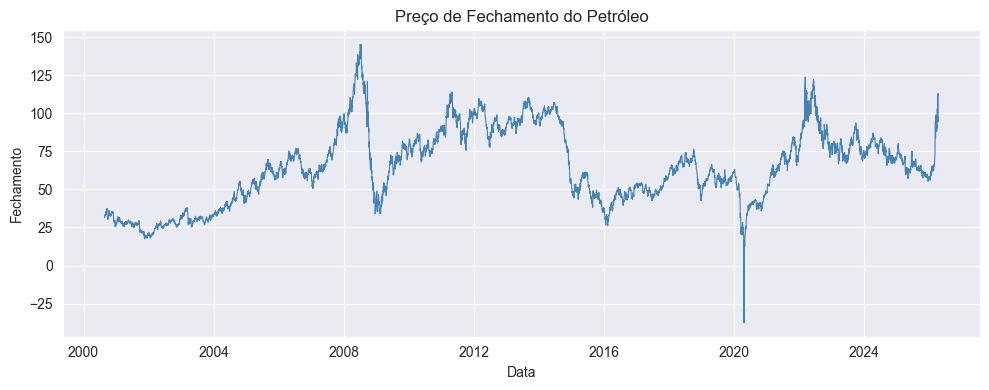

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(df["Data"], df["Fechamento"], label="Fechamento", color="steelblue", linewidth=.8)
plt.xlabel("Data")
plt.ylabel("Fechamento")
plt.title("Preço de Fechamento do Petróleo")
plt.tight_layout()
plt.show()

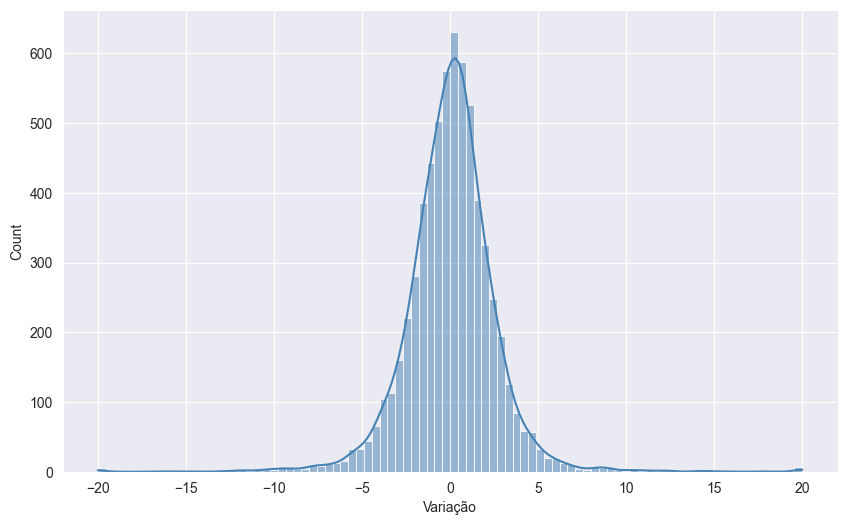

In [11]:
plt.figure(figsize=(10, 6))

returns = df["Variação"].clip(-20, 20)
sns.histplot(returns, bins=90, kde=True, color="steelblue")

plt.show()

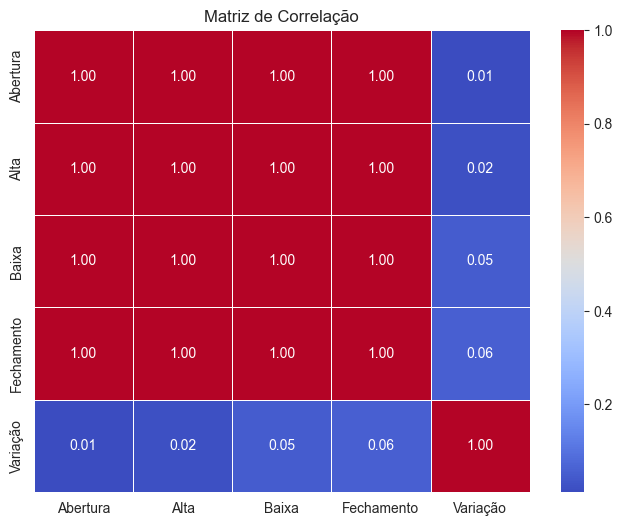

In [12]:
corr = df.drop(columns=["Data"]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação")
plt.show()

In [13]:
df['Dia'] = df['Data'].dt.day
df['Mes'] = df['Data'].dt.month
df['Ano'] = df['Data'].dt.year

df.head()

,Data,Abertura,Alta,Baixa,Fechamento,Variação,Dia,Mes,Ano
0,2000-08-23,31.950001,32.799999,31.950001,32.049999,0.00,23,8,2000
1,2000-08-24,31.900000,32.240002,31.400000,31.629999,-1.31,24,8,2000
2,2000-08-25,31.700001,32.099998,31.320000,32.049999,1.33,25,8,2000
3,2000-08-28,32.040001,32.919998,31.860001,32.869999,2.56,28,8,2000
4,2000-08-29,32.820000,33.029999,32.560001,32.720001,-0.46,29,8,2000


In [14]:
df['Fechamento_futuro_7d'] = df["Fechamento"].shift(-7)

df_clean = df.dropna(subset=['Fechamento_futuro_7d'])

features = ['Abertura', 'Alta', 'Baixa', 'Fechamento', 'Variação', 'Dia', 'Mes', 'Ano']
target = 'Fechamento_futuro_7d'

x = df_clean[features]
y = df_clean[target]    

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

print(len(x_train), len(x_test))



5142 1286


In [15]:
treinamento_modelo = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
    )

treinamento_modelo.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

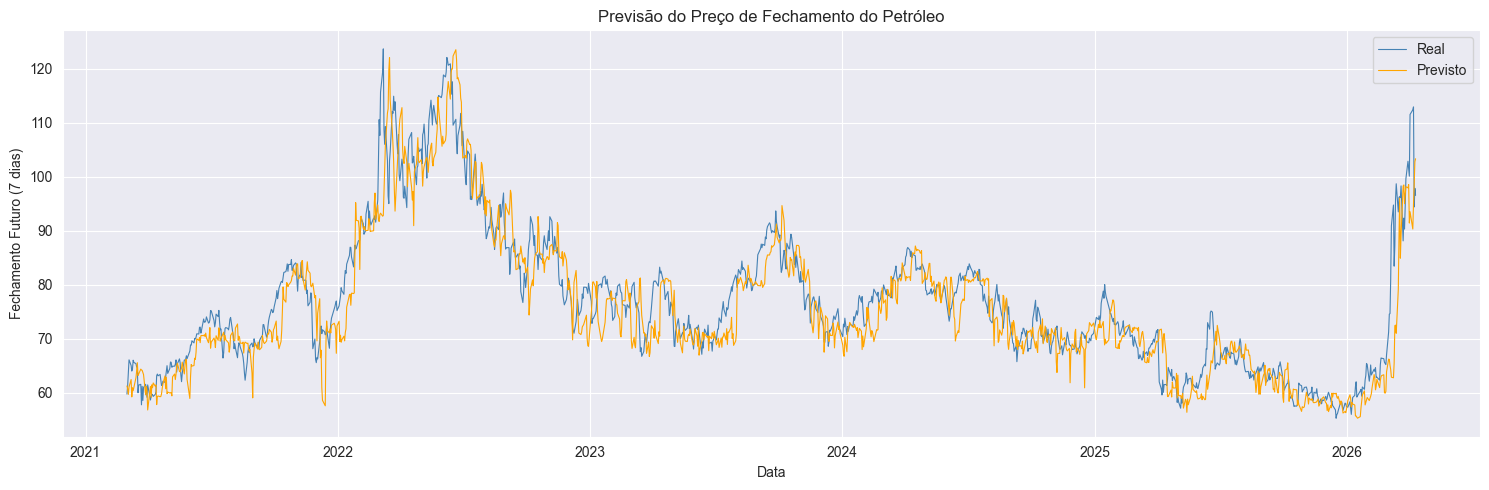

In [16]:
teste = df['Data'].iloc[-len(y_test):]

plt.figure(figsize=(15, 5))
plt.plot(teste, y_test, label="Real", color="steelblue", linewidth=.8)
plt.plot(teste, treinamento_modelo.predict(x_test), label="Previsto", color="orange", linewidth=.8)
plt.xlabel("Data")      
plt.ylabel("Fechamento Futuro (7 dias)")
plt.title("Previsão do Preço de Fechamento do Petróleo")    
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
y_pred = treinamento_modelo.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmae = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")    
print(f"RMAE: {rmae:.4f}")

R²: 0.8263
MAE: 3.8519
RMAE: 5.3696


In [29]:
ultima_data = df['Data'].max()
data_previsao = ultima_data + pd.Timedelta(days=7)


print(f"Preço previsto: {previsao[0]:.2f}")

print(f"Preço hoje: {df['Fechamento'].iloc[-1]:.2f}")

Preço previsto: 97.57
Preço hoje: 96.57
